# TNSA simplistic generator

In [2]:
#!/usr/bin/env python3
"""
Simple synthetic TNSA proton-spectrum model.

Written by ChatGPT with help from Scott Feister on 2026-06-16.

This is a toy model, not a real TNSA simulation.

Input:
    100-point laser intensity trace.

Output:
    protons_per_bin:
        number of protons in equally spaced energy bins.

Important simplification:
    Pre-pulse damage is based on absolute early-time intensity.

    The pre-pulse region is defined relative to the main pulse peak:

        pre-pulse region = all samples before peak_index - main_exclusion_width

    This avoids treating the rising edge of the main pulse as damaging pre-pulse.
"""

import numpy as np
import matplotlib.pyplot as plt


def make_proton_spectrum(
    intensity,
    n_energy_bins=200,
    max_energy_MeV=50.0,
    wavelength_um=0.8,
    main_exclusion_width=20,
    prepulse_damage_threshold_W_cm2=1.0e15,
):
    """
    Convert a 100-point laser intensity trace into a fake TNSA proton spectrum.

    Parameters
    ----------
    intensity:
        100-point laser intensity trace in W/cm^2.

    main_exclusion_width:
        Number of samples before the peak to ignore when checking for pre-pulse.

        Example:
            peak_index = 75
            main_exclusion_width = 20

            pre-pulse region = samples 0 through 54
            ignored/main region = samples 55 through 99

    prepulse_damage_threshold_W_cm2:
        Absolute intensity threshold where pre-pulse starts damaging the target.
    """

    intensity = np.asarray(intensity, dtype=float)

    if intensity.shape != (100,):
        raise ValueError("intensity must be a 100-point 1D array")

    if np.any(intensity < 0):
        raise ValueError("intensity cannot contain negative values")

    if np.max(intensity) <= 0:
        raise ValueError("intensity must contain at least one positive value")

    # ------------------------------------------------------------
    # Main pulse
    # ------------------------------------------------------------

    peak_index = int(np.argmax(intensity))
    peak_intensity = float(intensity[peak_index])

    # This is the key line:
    # pre-pulse is everything sufficiently before the main peak.
    prepulse_end_index = max(0, peak_index - main_exclusion_width)

    # ------------------------------------------------------------
    # Hot electron temperature from peak intensity
    # ------------------------------------------------------------

    I18 = peak_intensity / 1.0e18
    a0 = 0.85 * np.sqrt(I18 * wavelength_um**2)

    hot_electron_temp_MeV = 0.511 * (np.sqrt(1.0 + a0**2) - 1.0)

    # ------------------------------------------------------------
    # Absolute pre-pulse damage
    # ------------------------------------------------------------

    prepulse = intensity[:prepulse_end_index]

    if len(prepulse) == 0:
        max_prepulse_intensity = 0.0
    else:
        max_prepulse_intensity = float(np.max(prepulse))

    survival = 1.0

    # If the early absolute intensity is above the damage threshold,
    # reduce survival.
    if max_prepulse_intensity > prepulse_damage_threshold_W_cm2:
        survival *= prepulse_damage_threshold_W_cm2 / max_prepulse_intensity

    # If the pre-pulse is wildly above threshold, basically kill the shot.
    if max_prepulse_intensity > 100.0 * prepulse_damage_threshold_W_cm2:
        survival *= 0.01

    survival = float(np.clip(survival, 0.0, 1.0))

    # ------------------------------------------------------------
    # Proton spectrum parameters
    # ------------------------------------------------------------

    proton_cutoff_MeV = 8.0 * hot_electron_temp_MeV * survival

    failed_shot = proton_cutoff_MeV < 0.05

    if failed_shot:
        proton_cutoff_MeV = 0.05
        proton_temperature_MeV = 0.015
        total_protons = 1.0
    else:
        proton_temperature_MeV = proton_cutoff_MeV / 6.0
        total_protons = 1.0e9 * I18**0.7 * survival**2

    # ------------------------------------------------------------
    # Equally spaced energy bins
    # ------------------------------------------------------------

    energy_edges = np.linspace(0.0, max_energy_MeV, n_energy_bins + 1)
    energy_MeV = 0.5 * (energy_edges[:-1] + energy_edges[1:])

    E = energy_MeV

    spectrum_shape = np.exp(-E / proton_temperature_MeV)

    cutoff_width = max(0.1 * proton_cutoff_MeV, 0.05)
    cutoff = 1.0 / (1.0 + np.exp((E - proton_cutoff_MeV) / cutoff_width))

    spectrum_shape *= cutoff

    if np.sum(spectrum_shape) > 0:
        protons_per_bin = total_protons * spectrum_shape / np.sum(spectrum_shape)
    else:
        protons_per_bin = np.zeros_like(energy_MeV)

    info = {
        "peak_index": peak_index,
        "prepulse_end_index": prepulse_end_index,
        "main_exclusion_width": main_exclusion_width,
        "peak_intensity_W_cm2": peak_intensity,
        "a0": a0,
        "hot_electron_temp_MeV": hot_electron_temp_MeV,
        "max_prepulse_intensity_W_cm2": max_prepulse_intensity,
        "prepulse_damage_threshold_W_cm2": prepulse_damage_threshold_W_cm2,
        "survival": survival,
        "proton_cutoff_MeV": proton_cutoff_MeV,
        "proton_temperature_MeV": proton_temperature_MeV,
        "total_protons": total_protons,
        "failed_shot": failed_shot,
    }

    return energy_MeV, protons_per_bin, info


def make_realistic_trace(
    peak_intensity=5.0e19,
    *,
    main_center=75,
    main_width=3.0,
    ase_level=1.0e10,
    pedestal_level=1.0e12,
    prepulse_intensity=0.0,
    prepulse_center=25,
    prepulse_width=2.0,
    satellite_intensity=0.0,
    satellite_center=55,
    satellite_width=3.0,
    noise_fraction=0.03,
    random_seed=None,
):
    """
    Make a more realistic 100-point laser intensity trace.

    Components:
        main pulse
        ASE-like floor
        slowly rising pedestal
        isolated early pre-pulse
        satellite pulse
        small multiplicative noise
    """

    rng = np.random.default_rng(random_seed)

    t = np.arange(100)

    main_pulse = peak_intensity * np.exp(
        -0.5 * ((t - main_center) / main_width) ** 2
    )

    ase = ase_level * np.ones_like(t, dtype=float)

    pedestal = np.zeros_like(t, dtype=float)
    before_main = t < main_center
    pedestal[before_main] = pedestal_level * np.exp(
        -(main_center - t[before_main]) / 18.0
    )

    prepulse = prepulse_intensity * np.exp(
        -0.5 * ((t - prepulse_center) / prepulse_width) ** 2
    )

    satellite = satellite_intensity * np.exp(
        -0.5 * ((t - satellite_center) / satellite_width) ** 2
    )

    intensity = main_pulse + ase + pedestal + prepulse + satellite

    if noise_fraction > 0:
        noise = rng.normal(loc=1.0, scale=noise_fraction, size=100)
        noise = np.clip(noise, 0.0, None)
        intensity *= noise

    return intensity

C:\Users\scott\AppData\Local\Temp\ipykernel_39976\2862626531.py:143: RuntimeWarning: overflow encountered in exp
  cutoff = 1.0 / (1.0 + np.exp((E - proton_cutoff_MeV) / cutoff_width))



Synthetic TNSA demo summary

clean high power
----------------
  peak_index:                  75
  prepulse_end_index:          55
  peak_intensity_W_cm2:        5.134e+19
  max_prepulse_intensity:      9.763e+11
  prepulse_damage_threshold:   1.000e+15
  survival:                    1.000e+00
  hot_electron_temp_MeV:       2.031
  proton_cutoff_MeV:           16.246
  total_protons:               1.575e+10
  failed_shot:                 False

clean lower power
-----------------
  peak_index:                  75
  prepulse_end_index:          55
  peak_intensity_W_cm2:        7.699e+18
  max_prepulse_intensity:      9.528e+11
  prepulse_damage_threshold:   1.000e+15
  survival:                    1.000e+00
  hot_electron_temp_MeV:       0.580
  proton_cutoff_MeV:           4.642
  total_protons:               4.174e+09
  failed_shot:                 False

dirty high power
----------------
  peak_index:                  76
  prepulse_end_index:          56
  peak_intensity_W_cm2:    

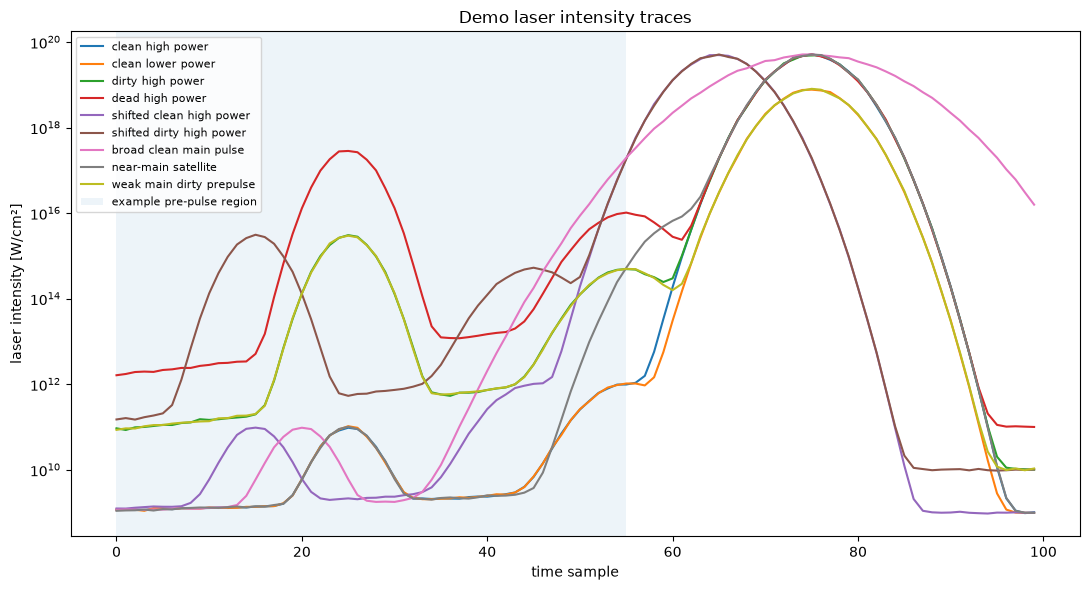

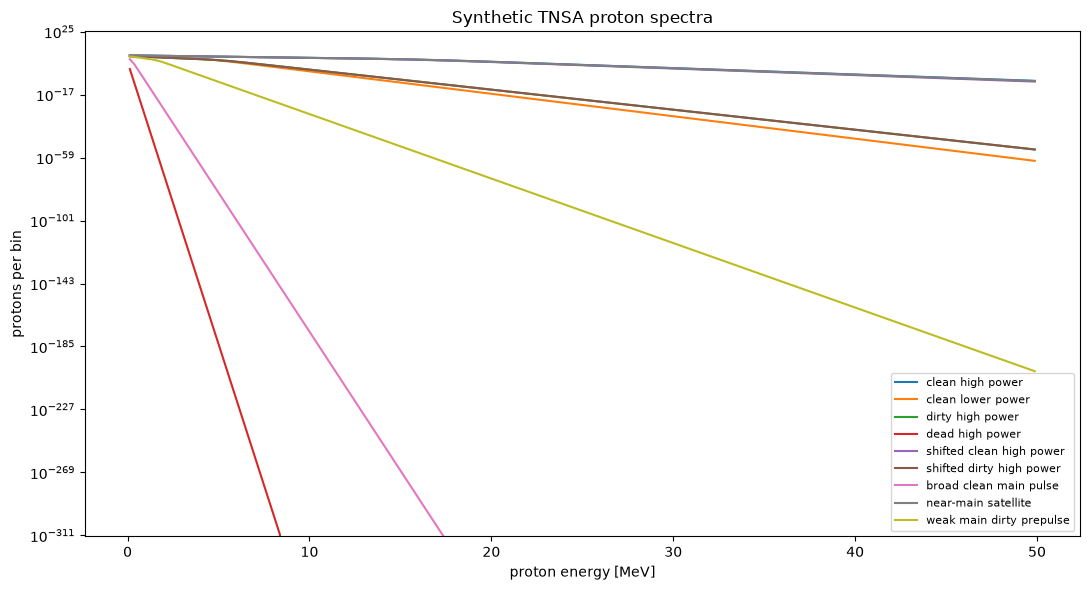

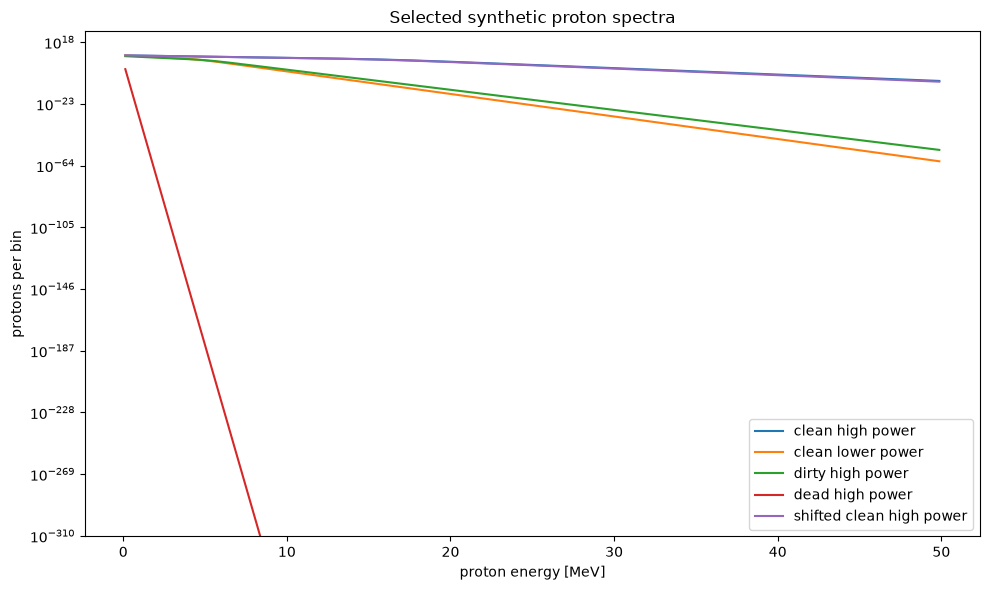

In [3]:
if __name__ == "__main__":

    # ------------------------------------------------------------
    # Demo cases
    # ------------------------------------------------------------
    #
    # These examples are designed to show:
    #
    #   1. Clean high-power TNSA
    #   2. Lower-power but clean TNSA
    #   3. Dirty pre-pulse suppression
    #   4. Completely dead target from huge pre-pulse
    #   5. Temporal shift invariance relative to the peak
    #   6. Broad main pulse behavior
    #   7. Satellite pulse near the main pulse that is not counted as pre-pulse
    #   8. Weak main pulse plus damaging pre-pulse
    #
    # The TNSA model uses:
    #
    #   pre-pulse region = samples before peak_index - main_exclusion_width
    #
    # so shifting the whole pulse earlier/later should not automatically
    # change the answer, unless the relative pre-pulse timing changes.

    main_exclusion_width = 20

    traces = {
        # Strong main pulse, very low early-time junk.
        "clean high power": make_realistic_trace(
            peak_intensity=5.0e19,
            main_center=75,
            main_width=3.0,
            ase_level=1.0e9,
            pedestal_level=1.0e10,
            prepulse_intensity=1.0e11,
            prepulse_center=25,
            satellite_intensity=1.0e12,
            satellite_center=55,
            random_seed=1,
        ),

        # Same clean contrast, but lower peak intensity.
        "clean lower power": make_realistic_trace(
            peak_intensity=8.0e18,
            main_center=75,
            main_width=3.0,
            ase_level=1.0e9,
            pedestal_level=1.0e10,
            prepulse_intensity=1.0e11,
            prepulse_center=25,
            satellite_intensity=1.0e12,
            satellite_center=55,
            random_seed=2,
        ),

        # Pre-pulse is above the absolute damage threshold.
        "dirty high power": make_realistic_trace(
            peak_intensity=5.0e19,
            main_center=75,
            main_width=3.0,
            ase_level=1.0e10,
            pedestal_level=5.0e12,
            prepulse_intensity=3.0e15,
            prepulse_center=25,
            satellite_intensity=5.0e14,
            satellite_center=55,
            random_seed=3,
        ),

        # Very large early pre-pulse: target is basically destroyed.
        "dead high power": make_realistic_trace(
            peak_intensity=5.0e19,
            main_center=75,
            main_width=3.0,
            ase_level=1.0e11,
            pedestal_level=1.0e14,
            prepulse_intensity=3.0e17,
            prepulse_center=25,
            satellite_intensity=1.0e16,
            satellite_center=55,
            random_seed=4,
        ),

        # Same as clean high power, but shifted earlier in time.
        # Should be similar to "clean high power" because pre-pulse is
        # measured relative to the peak index.
        "shifted clean high power": make_realistic_trace(
            peak_intensity=5.0e19,
            main_center=65,
            main_width=3.0,
            ase_level=1.0e9,
            pedestal_level=1.0e10,
            prepulse_intensity=1.0e11,
            prepulse_center=15,
            satellite_intensity=1.0e12,
            satellite_center=45,
            random_seed=5,
        ),

        # Same as dirty high power, but shifted earlier in time.
        # Should be similar to "dirty high power".
        "shifted dirty high power": make_realistic_trace(
            peak_intensity=5.0e19,
            main_center=65,
            main_width=3.0,
            ase_level=1.0e10,
            pedestal_level=5.0e12,
            prepulse_intensity=3.0e15,
            prepulse_center=15,
            satellite_intensity=5.0e14,
            satellite_center=45,
            random_seed=6,
        ),

        # Broader main pulse. Peak is the same, so hot-electron temperature
        # is similar, but the trace shape looks more realistic for a longer pulse.
        # This simple model mostly cares about peak intensity and pre-pulse.
        "broad clean main pulse": make_realistic_trace(
            peak_intensity=5.0e19,
            main_center=75,
            main_width=6.0,
            ase_level=1.0e9,
            pedestal_level=1.0e10,
            prepulse_intensity=1.0e11,
            prepulse_center=20,
            satellite_intensity=1.0e12,
            satellite_center=52,
            random_seed=7,
        ),

        # Big satellite near the main pulse, but inside the excluded region.
        # This should not count as target-damaging pre-pulse.
        "near-main satellite": make_realistic_trace(
            peak_intensity=5.0e19,
            main_center=75,
            main_width=3.0,
            ase_level=1.0e9,
            pedestal_level=1.0e10,
            prepulse_intensity=1.0e11,
            prepulse_center=25,
            satellite_intensity=8.0e15,
            satellite_center=62,
            random_seed=8,
        ),

        # Lower main pulse with bad pre-pulse.
        # Shows that absolute pre-pulse damage is not normalized to peak.
        "weak main dirty prepulse": make_realistic_trace(
            peak_intensity=8.0e18,
            main_center=75,
            main_width=3.0,
            ase_level=1.0e10,
            pedestal_level=5.0e12,
            prepulse_intensity=3.0e15,
            prepulse_center=25,
            satellite_intensity=5.0e14,
            satellite_center=55,
            random_seed=9,
        ),
    }

    # ------------------------------------------------------------
    # Run model
    # ------------------------------------------------------------

    results = {}

    for name, trace in traces.items():
        energy, spectrum, info = make_proton_spectrum(
            trace,
            main_exclusion_width=main_exclusion_width,
        )

        results[name] = {
            "trace": trace,
            "energy": energy,
            "spectrum": spectrum,
            "info": info,
        }

    # ------------------------------------------------------------
    # Print compact summary
    # ------------------------------------------------------------

    print()
    print("Synthetic TNSA demo summary")
    print("=" * 80)

    for name, result in results.items():
        info = result["info"]

        print()
        print(name)
        print("-" * len(name))
        print(f"  peak_index:                  {info['peak_index']}")
        print(f"  prepulse_end_index:          {info['prepulse_end_index']}")
        print(f"  peak_intensity_W_cm2:        {info['peak_intensity_W_cm2']:.3e}")
        print(f"  max_prepulse_intensity:      {info['max_prepulse_intensity_W_cm2']:.3e}")
        print(f"  prepulse_damage_threshold:   {info['prepulse_damage_threshold_W_cm2']:.3e}")
        print(f"  survival:                    {info['survival']:.3e}")
        print(f"  hot_electron_temp_MeV:       {info['hot_electron_temp_MeV']:.3f}")
        print(f"  proton_cutoff_MeV:           {info['proton_cutoff_MeV']:.3f}")
        print(f"  total_protons:               {info['total_protons']:.3e}")
        print(f"  failed_shot:                 {info['failed_shot']}")

    # ------------------------------------------------------------
    # Plot laser traces
    # ------------------------------------------------------------

    plt.figure(figsize=(11, 6))

    for name, result in results.items():
        plt.plot(result["trace"], label=name)

    plt.axvspan(
        0,
        results["clean high power"]["info"]["prepulse_end_index"],
        alpha=0.08,
        label="example pre-pulse region",
    )

    plt.yscale("log")
    plt.xlabel("time sample")
    plt.ylabel("laser intensity [W/cm²]")
    plt.title("Demo laser intensity traces")
    plt.legend(fontsize=8)
    plt.tight_layout()

    # ------------------------------------------------------------
    # Plot proton spectra
    # ------------------------------------------------------------

    plt.figure(figsize=(11, 6))

    for name, result in results.items():
        plt.plot(
            result["energy"],
            result["spectrum"],
            label=name,
        )

    plt.yscale("log")
    plt.xlabel("proton energy [MeV]")
    plt.ylabel("protons per bin")
    plt.title("Synthetic TNSA proton spectra")
    plt.legend(fontsize=8)
    plt.tight_layout()

    # ------------------------------------------------------------
    # Plot only selected spectra for readability
    # ------------------------------------------------------------

    selected_names = [
        "clean high power",
        "clean lower power",
        "dirty high power",
        "dead high power",
        "shifted clean high power",
    ]

    plt.figure(figsize=(10, 6))

    for name in selected_names:
        result = results[name]
        plt.plot(
            result["energy"],
            result["spectrum"],
            label=name,
        )

    plt.yscale("log")
    plt.xlabel("proton energy [MeV]")
    plt.ylabel("protons per bin")
    plt.title("Selected synthetic proton spectra")
    plt.legend()
    plt.tight_layout()

    plt.show()